# **VGG16+GA+XGBoost**

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder  # <-- add this
from tensorflow.keras.utils import to_categorical

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm
import warnings
import time
import cv2
from concurrent.futures import ThreadPoolExecutor

# Start timing
st = time.time()
warnings.filterwarnings("ignore")

class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, label_map):
        self.image_paths = image_paths
        self.labels = labels
        self.label_map = label_map
        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),  # VGG16 uses 224x224
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            image_tensor = self.preprocess(image)
            label_idx = self.label_map[label]
            return image_tensor, label_idx, img_path
        except (UnidentifiedImageError, Exception) as e:
            print(f"Error loading image {img_path}: {e}")
            return torch.zeros(3, 224, 224), -1, img_path  # Dummy for invalid image

def extract_features(image_paths, labels, device=None,
                     batch_size=16, num_workers=4, save_features=False,
                     output_dir='features', label_map=None):

    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if len(image_paths) != len(labels):
        raise ValueError("Number of image paths and labels must match.")
    if len(image_paths) == 0:
        print("No images provided.")
        return np.array([]), np.array([]), []

    # Load pretrained VGG16
    model = models.vgg16(pretrained=True)
    model = model.features  # Use only the convolutional base
    model.eval().to(device)

    dataset = ImageDataset(image_paths, labels, label_map=label_map)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            num_workers=num_workers, shuffle=False,
                            pin_memory=(device != 'cpu'))

    features, extracted_labels, valid_paths = [], [], []

    for batch_tensors, batch_labels, batch_paths in tqdm(dataloader, desc="Extracting features"):
        batch_tensors = batch_tensors.to(device)
        valid_mask = batch_labels != -1
        if valid_mask.sum() == 0:
            continue

        with torch.no_grad():
            # Pass through VGG16 convolutional layers
            conv_feats = model(batch_tensors[valid_mask])
            # Apply global average pooling to get [B, 512]
            batch_feat = torch.nn.functional.adaptive_avg_pool2d(conv_feats, (1, 1)).view(conv_feats.size(0), -1)
            batch_feat = batch_feat.cpu().numpy()

        features.append(batch_feat)
        extracted_labels.extend(batch_labels[valid_mask].cpu().numpy())
        valid_paths.extend([batch_paths[i] for i in range(len(batch_paths)) if valid_mask[i]])

    if not features:
        print("No valid images processed.")
        return np.empty((0, 512)), np.array([]), []

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)

    if save_features:
        os.makedirs(output_dir, exist_ok=True)
        np.save(os.path.join(output_dir, 'features.npy'), features)
        np.save(os.path.join(output_dir, 'labels.npy'), extracted_labels)
        with open(os.path.join(output_dir, 'valid_paths.txt'), 'w') as f:
            f.write('\n'.join(valid_paths))
        print(f"Features saved to {output_dir}")

    print(f"Extracted {features.shape[0]} features.")
    return features, extracted_labels, valid_paths

def get_image_paths_and_labels(folder_path):
    image_paths, labels, label_map = [], [], {}
    for idx, label_name in enumerate(sorted(os.listdir(folder_path))):
        label_folder = os.path.join(folder_path, label_name)
        if os.path.isdir(label_folder):
            label_map[label_name] = idx
            for filename in os.listdir(label_folder):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(label_folder, filename))
                    labels.append(label_name)
    return image_paths, labels, label_map

# Folder paths
train_folder = "/kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Train and Validation Set"
test_folder = "/kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Test Set"

# Load image paths and labels
x_train_paths, y_train, train_label_map = get_image_paths_and_labels(train_folder)
x_test_paths, y_test, test_label_map = get_image_paths_and_labels(test_folder)

# Confirm device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Extract test features
print("Extracting features for test set...")
xtest_features, y_test_labels, _ = extract_features(
    x_test_paths, y_test, device=device, batch_size=16,
    num_workers=4, save_features=True,
    output_dir='test_features', label_map=test_label_map
)

# Extract train features
print("Extracting features for training set...")
xtrain_features, y_train_labels, _ = extract_features(
    x_train_paths, y_train, device=device, batch_size=16,
    num_workers=4, save_features=True,
    output_dir='train_features', label_map=train_label_map
)

# Output shapes
print(f"Train features shape: {xtrain_features.shape}")
print(f"Train labels shape: {y_train_labels.shape}")
print(f"Test features shape: {xtest_features.shape}")
print(f"Test labels shape: {y_test_labels.shape}")

# End timing
end = time.time()
print(f"Total execution time: {end - st:.2f} seconds")


Using device: cuda
Extracting features for test set...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 245MB/s] 
Extracting features: 100%|██████████| 157/157 [00:14<00:00, 10.78it/s]


Features saved to test_features
Extracted 2499 features.
Extracting features for training set...


Extracting features: 100%|██████████| 1407/1407 [02:04<00:00, 11.32it/s]

Features saved to train_features
Extracted 22501 features.
Train features shape: (22501, 512)
Train labels shape: (22501,)
Test features shape: (2499, 512)
Test labels shape: (2499,)
Total execution time: 145.16 seconds


In [3]:
# Save to NPZ
np.savez(
    "features_VGG16.npz",
    xtrain_features=xtrain_features,
    y_train_labels=y_train_labels,
    xtest_features=xtest_features,
    y_test_labels=y_test_labels
)

print("features_VGG16.npz")

features_VGG16.npz


# GA without K-fold cross validation

 Đang chạy trên 2 thiết bị: [device(type='cuda', index=0), device(type='cuda', index=1)]
DANG CHAY GA TREN 2X GPU KAGGLE...
Generation 001: Best Fitness = 0.3070, Average Fitness = 0.2949, Selected Features = 260
Generation 002: Best Fitness = 0.3070, Average Fitness = 0.2998, Selected Features = 260
Generation 003: Best Fitness = 0.3070, Average Fitness = 0.3018, Selected Features = 260
Generation 004: Best Fitness = 0.3070, Average Fitness = 0.3028, Selected Features = 260
Generation 005: Best Fitness = 0.3082, Average Fitness = 0.3041, Selected Features = 260
Generation 006: Best Fitness = 0.3104, Average Fitness = 0.3046, Selected Features = 254
Generation 007: Best Fitness = 0.3115, Average Fitness = 0.3059, Selected Features = 271
Generation 008: Best Fitness = 0.3128, Average Fitness = 0.3066, Selected Features = 276
Generation 009: Best Fitness = 0.3128, Average Fitness = 0.3075, Selected Features = 276
Generation 010: Best Fitness = 0.3128, Average Fitness = 0.3077, Selected F

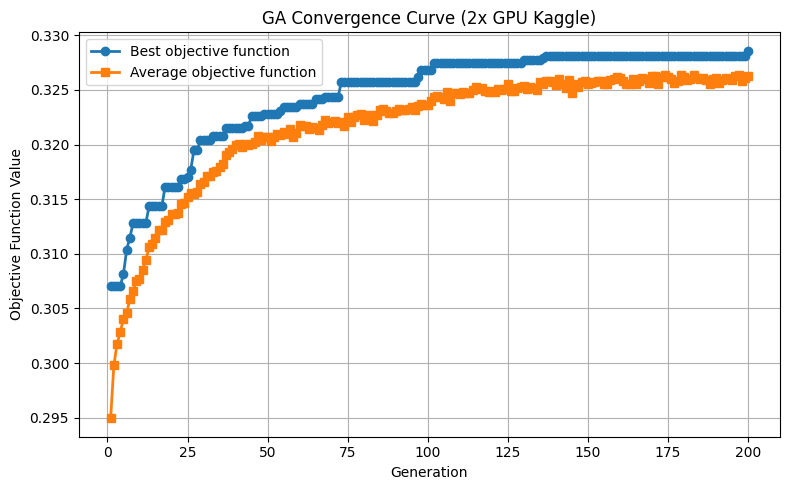

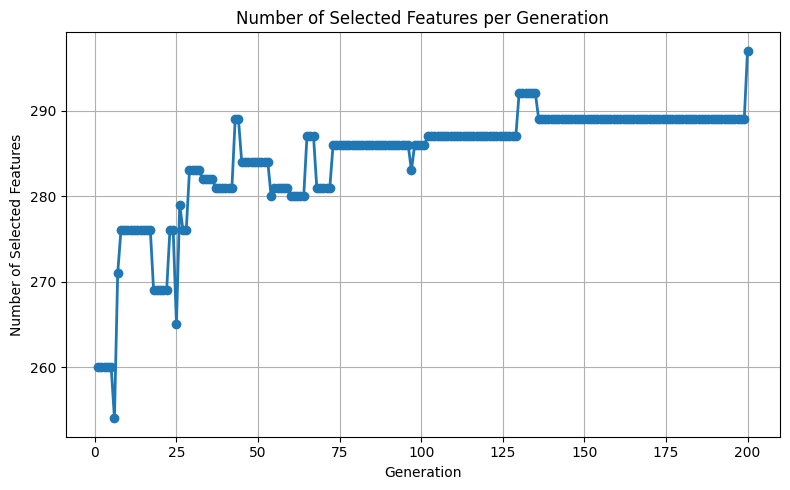

In [10]:
import os
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

st = time.time()

# --------- Sửa lỗi tên biến ở code gốc & Pre-split Data ---------
X_tr, X_val, y_tr, y_val = train_test_split(
    xtrain_features,
    y_train_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_train_labels,
)

# Chuyển dữ liệu sang PyTorch Tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# Thiết lập 2 GPU Kaggle (cuda:0 và cuda:1)
devices = [
    torch.device(f"cuda:{i}")
    for i in range(torch.cuda.device_count())
    if torch.cuda.is_available()
]
if len(devices) < 2:
  devices = [torch.device("cuda:0")] if torch.cuda.is_available() else [torch.device("cpu")]

print(f" Đang chạy trên {len(devices)} thiết bị: {devices}")


# --------- Hàm Logistic Regression siêu nhanh trên GPU bằng PyTorch ---------
def evaluate_batch_gpu(population_subset, device, X_tr_t, y_tr_t, X_val_t, y_val_t):
  X_tr_d = X_tr_t.to(device)
  y_tr_d = y_tr_t.to(device).unsqueeze(1)
  X_val_d = X_val_t.to(device)
  y_val_d = y_val_t.to(device)

  scores = []
  for ind in population_subset:
    selected = torch.tensor(ind, dtype=torch.bool, device=device)
    if not selected.any():
      scores.append(0.0)
      continue

    X_tr_sub = X_tr_d[:, selected]
    X_val_sub = X_val_d[:, selected]

    # Logistic Regression via Solved Ridge Closed-Form / Gradient Ascent optimization on GPU
    # Thêm bias term
    ones_tr = torch.ones((X_tr_sub.shape[0], 1), device=device)
    X_b_tr = torch.cat([ones_tr, X_tr_sub], dim=1)

    ones_val = torch.ones((X_val_sub.shape[0], 1), device=device)
    X_b_val = torch.cat([ones_val, X_val_sub], dim=1)

    # Chạy Ridge Classification cực nhanh bằng Ma trận (Closed form solution)
    reg = 1e-4 * torch.eye(X_b_tr.shape[1], device=device)
    weights = (
        torch.linalg.pinv(X_b_tr.T @ X_b_tr + reg)
        @ X_b_tr.T
        @ (y_tr_d * 2 - 1)
    )

    # Dự đoán trên tập Validation
    preds = (X_b_val @ weights) > 0
    acc = (preds.squeeze() == y_val_d).float().mean().item()
    scores.append(acc)

  return scores


# --------- Step 4: Genetic Algorithm (Parallel 2x GPU) ---------
def genetic_algorithm(
    pop_size=50,
    generations=400,
    mutation_rate=0.01,
):
  n_features = X_tr.shape[1]
  population = [
      np.random.randint(0, 2, n_features).astype(bool) for _ in range(pop_size)
  ]

  best_history, avg_history, feature_count_history = [], [], []
  best_individual_overall = None
  best_fitness_overall = -1.0

  for gen in range(generations):
    # Chia Quần thể (Population) làm 2 phần chạy song song trên 2 GPU
    split_size = len(population) // len(devices)
    scores = []

    # Chia việc cho từng GPU
    for i, dev in enumerate(devices):
      sub_pop = (
          population[i * split_size :]
          if i == len(devices) - 1
          else population[i * split_size : (i + 1) * split_size]
      )
      sub_scores = evaluate_batch_gpu(
          sub_pop, dev, X_tr_t, y_tr_t, X_val_t, y_val_t
      )
      scores.extend(sub_scores)

    scores = np.array(scores)

    # Lấy chỉ số tốt nhất
    best_idx = np.argmax(scores)
    best_ind = population[best_idx].copy()
    best_score = scores[best_idx]
    avg_score = np.mean(scores)

    best_history.append(best_score)
    avg_history.append(avg_score)
    feature_count_history.append(np.sum(best_ind))

    if best_score > best_fitness_overall:
      best_fitness_overall = best_score
      best_individual_overall = best_ind.copy()

    print(
        f"Generation {gen+1:03d}: Best Fitness = {best_score:.4f}, "
        f"Average Fitness = {avg_score:.4f}, Selected Features = {np.sum(best_ind)}"
    )

    # Chọn lọc top 50%
    sorted_pairs = sorted(
        zip(scores, population), key=lambda x: x[0], reverse=True
    )
    population = [ind for _, ind in sorted_pairs[: pop_size // 2]]

    # Crossover + Vectorized Mutation
    while len(population) < pop_size:
      p1, p2 = random.sample(population, 2)
      cp = random.randint(1, n_features - 1)
      child = np.concatenate([p1[:cp], p2[cp:]])

      # Mutation nhanh bằng Numpy Vectorization
      mutation_mask = np.random.rand(n_features) < mutation_rate
      child[mutation_mask] = ~child[mutation_mask]

      population.append(child.astype(bool))

  return (
      best_individual_overall,
      best_fitness_overall,
      best_history,
      avg_history,
      feature_count_history,
  )


# --------- Step 5: Chạy GA & Đánh giá Model cuối cùng ---------
print("DANG CHAY GA TREN 2X GPU KAGGLE...")
(
    best_individual,
    best_fitness,
    best_history,
    avg_history,
    feature_count_history,
) = genetic_algorithm(pop_size=50, generations=200)

# Chạy mô hình Logistic Regression cuối cùng trên CPU/Sklearn với các đặc trưng được chọn
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(xtrain_features[:, best_individual], y_train_labels)
y_pred = clf.predict(xtest_features[:, best_individual])
test_acc = accuracy_score(y_test_labels, y_pred)

print(f"\n Best Validation Accuracy từ GA: {best_fitness:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")
print(f" Số lượng đặc trưng được chọn: {np.sum(best_individual)}")

end = time.time()
print(f" Tổng thời gian thực thi: {end - st:.2f} giây")

# --------- Step 6: Vẽ biểu đồ convergence ---------
generations = range(1, len(best_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    generations,
    best_history,
    marker="o",
    linewidth=2,
    label="Best objective function",
)
plt.plot(
    generations,
    avg_history,
    marker="s",
    linewidth=2,
    label="Average objective function",
)
plt.title("GA Convergence Curve (2x GPU Kaggle)")
plt.xlabel("Generation")
plt.ylabel("Objective Function Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_convergence_curve_MRI.png", dpi=300, bbox_inches="tight")
plt.show()

# --------- Step 7: Vẽ biểu đồ số lượng feature ---------
plt.figure(figsize=(8, 5))
plt.plot(generations, feature_count_history, marker="o", linewidth=2)
plt.title("Number of Selected Features per Generation")
plt.xlabel("Generation")
plt.ylabel("Number of Selected Features")
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_selected_features_MRI.png", dpi=300, bbox_inches="tight")
plt.show()


 Test accuracy using selected features (XGBoost): 0.9860


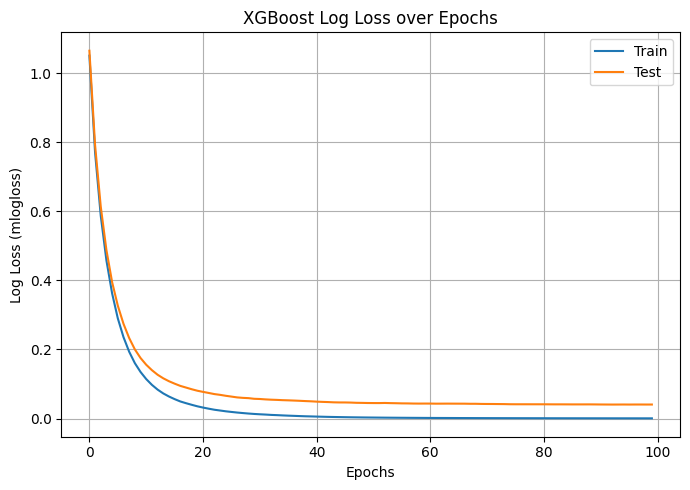

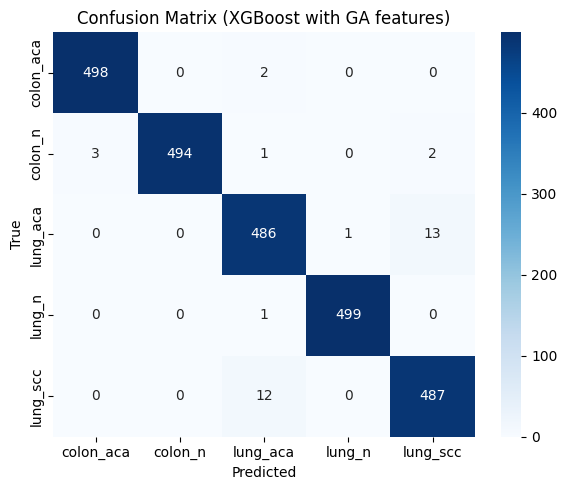


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       500
           1       1.00      0.99      0.99       500
           2       0.97      0.97      0.97       500
           3       1.00      1.00      1.00       500
           4       0.97      0.98      0.97       499

    accuracy                           0.99      2499
   macro avg       0.99      0.99      0.99      2499
weighted avg       0.99      0.99      0.99      2499

⏱️ Total Time: 4.78 seconds


In [13]:
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,)
from xgboost import XGBClassifier

st = time.time()


# --------- Step 1: Chọn đặc trưng đã chọn bởi GA ---------
X_train_selected = xtrain_features[:, best_individual]
X_test_selected = xtest_features[:, best_individual]

# --------- Step 2: Cấu hình và huấn luyện XGBoost ---------
clf = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",  # Tối ưu hóa tốc độ
    device="cuda",  # Chạy trên GPU (chuyển thành 'cpu' nếu không dùng GPU)
    verbosity=0,
    random_state=42,)


clf.fit(
    X_train_selected,
    y_train_labels,
    eval_set=[(X_train_selected, y_train_labels), (X_test_selected, y_test_labels)],
    verbose=False,
)

# Lấy logloss theo từng epoch
evals_result = clf.evals_result()

# --------- Step 3: Dự đoán trên Test Set ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test_labels, y_pred)
print(
    f"\n Test accuracy using selected features (XGBoost): {test_accuracy:.4f}"
)

# --------- Step 4: Vẽ biểu đồ Log Loss ---------
epochs = len(evals_result["validation_0"]["mlogloss"])
x_axis = range(0, epochs)

plt.figure(figsize=(7, 5))
plt.plot(x_axis, evals_result["validation_0"]["mlogloss"], label="Train")
plt.plot(x_axis, evals_result["validation_1"]["mlogloss"], label="Test")
plt.xlabel("Epochs")
plt.ylabel("Log Loss (mlogloss)")
plt.title("XGBoost Log Loss over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("XGBoost_mlogloss.png", dpi=300, bbox_inches="tight")
plt.show()

# --------- Step 5: Vẽ Confusion Matrix ---------
cm = confusion_matrix(y_test_labels, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (XGBoost with GA features)")
plt.tight_layout()
plt.savefig("CM_MRIEX2.png", dpi=300, bbox_inches="tight")
plt.show()

# --------- Step 6: Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred))

end = time.time()
print(f"⏱️ Total Time: {end - st:.2f} seconds")

# GA with K fold cross validation

In [ ]:
import os
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
# --- MODIFIED: Import LogisticRegression instead of GaussianNB ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image

st = time.time()


# --------- Step 4: Genetic Algorithm (Parallel version) ---------
def genetic_algorithm(
    X, y, pop_size=50, generations=200, mutation_rate=0.01, n_jobs=-1
):
  n_features = X.shape[1]
  population = [
      np.random.randint(0, 2, n_features).astype(bool) for _ in range(pop_size)
  ]

  best_history = []
  avg_history = []
  feature_count_history = []

  def fitness(individual):
    selected_features = individual.astype(bool)

    if not np.any(selected_features):
      return 0

    X_subset = X[:, selected_features]

    # --- MODIFIED: Instantiated LogisticRegression ---
    clf = LogisticRegression(max_iter=1000)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        clf, X_subset, y, cv=cv, scoring="accuracy", n_jobs=1
    )
    return scores.mean()

  best_individual_overall = None
  best_fitness_overall = -1

  for gen in range(generations):
    # Parallel evaluation of fitness
    scores = Parallel(n_jobs=n_jobs)(
        delayed(fitness)(ind) for ind in population
    )
    scores = np.array(scores)

    # Best and average objective values
    best_idx = np.argmax(scores)
    best_ind = population[best_idx].copy()
    best_score = scores[best_idx]
    avg_score = np.mean(scores)

    best_history.append(best_score)
    avg_history.append(avg_score)
    feature_count_history.append(np.sum(best_ind))

    # Update global best
    if best_score > best_fitness_overall:
      best_fitness_overall = best_score
      best_individual_overall = best_ind.copy()

    print(
        f"Generation {gen+1}: "
        f"Best Fitness = {best_score:.4f}, "
        f"Average Fitness = {avg_score:.4f}, "
        f"Selected Features = {np.sum(best_ind)}"
    )

    # Select top 50%
    sorted_pairs = sorted(
        zip(scores, population), key=lambda x: x[0], reverse=True
    )
    population = [ind for _, ind in sorted_pairs[: pop_size // 2]]

    # Crossover + mutation
    while len(population) < pop_size:
      p1, p2 = random.sample(population, 2)
      cp = random.randint(1, n_features - 1)
      child = np.concatenate([p1[:cp], p2[cp:]])

      for i in range(n_features):
        if random.random() < mutation_rate:
          child[i] = not child[i]

      population.append(child.astype(bool))

  return (
      best_individual_overall,
      best_fitness_overall,
      best_history,
      avg_history,
      feature_count_history,
  )


# --------- Step 5: Running GA and final classifier ---------
print("Running GA...")
(
    best_individual,
    best_fitness,
    best_history,
    avg_history,
    feature_count_history,
) = genetic_algorithm(features_train, y_train, n_jobs=-1)

# --- MODIFIED: Used LogisticRegression for the final evaluation ---
clf = LogisticRegression(max_iter=1000)
clf.fit(features_train[:, best_individual], y_train)
y_pred = clf.predict(features_test[:, best_individual])
test_acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Best CV Accuracy from GA: {best_fitness:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of selected features: {np.sum(best_individual)}")

end = time.time()
print("Total Time:", end - st)


# --------- Step 6: Plot GA convergence ---------
generations = range(1, len(best_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    generations,
    best_history,
    marker="o",
    linewidth=2,
    label="Best objective function",
)
plt.plot(
    generations,
    avg_history,
    marker="s",
    linewidth=2,
    label="Average objective function",
)
plt.title("GA Convergence Curve")
plt.xlabel("Generation")
plt.ylabel("Objective Function Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_convergence_curve_MRI.png", dpi=300, bbox_inches="tight")
plt.show()


# --------- Step 7: Plot number of selected features ---------
plt.figure(figsize=(8, 5))
plt.plot(generations, feature_count_history, marker="o", linewidth=2)
plt.title("Number of Selected Features per Generation")
plt.xlabel("Generation")
plt.ylabel("Number of Selected Features")
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_selected_features_MRI.png", dpi=300, bbox_inches="tight")
plt.show()

**Other alogirthms**

In [5]:
import os
import numpy as np
import torch
from PIL import Image, UnidentifiedImageError
from concurrent.futures import ThreadPoolExecutor

def process_image(img_path, feature_extractor, model, device):
    try:
        # Load and preprocess image
        image = Image.open(img_path).convert("RGB")

        # Preprocess with feature extractor
        inputs = feature_extractor(image, return_tensors="pt").to(device)

        # Extract features
        with torch.no_grad():
            outputs = model(**inputs)

        # Take CLS token feature
        cls_token_feature = outputs.last_hidden_state[:, 0, :]  # CLS token
        return cls_token_feature.cpu().numpy().flatten()

    except UnidentifiedImageError:
        print(f"Warning: Unable to identify image file: {img_path}. Skipping.")
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
    return None
def extract_features(image_paths, feature_extractor, model, device, num_workers=4):
    features = []

    # Define a helper function that wraps process_image
    def process(img_path):
        return process_image(img_path, feature_extractor, model, device)

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process, image_paths))

    # Remove failed images
    features = np.array([res for res in results if res is not None])
    return features

XGBoost

In [8]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import time

st = time.time()
# Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Fit & transform y_train
y_test_encoded = label_encoder.transform(y_test)        # Only transform y_test

# Step 5: Train an XGBoost Classifier
classifier = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
classifier.fit(features_train, y_train_encoded)  # Training with encoded labels  

# Step 6: Make Predictions
y_pred_encoded = classifier.predict(features_test)

# Step 7: Decode predictions back to original labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Step 8: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

nd = time.time()
print("Thoi gian thu thi:", nd - st)

Accuracy: 0.9943977591036415
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       0.99      0.99      0.99       500
           3       1.00      1.00      1.00       500
           4       0.99      0.99      0.99       499

    accuracy                           0.99      2499
   macro avg       0.99      0.99      0.99      2499
weighted avg       0.99      0.99      0.99      2499

Thoi gian thu thi: 45.469550371170044


<function matplotlib.pyplot.show(close=None, block=None)>

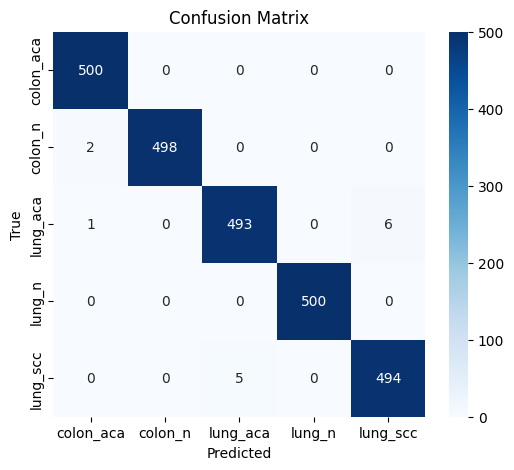

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Step 7: Evaluate the Model and Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)  # Define conf_matrix here
class_names = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
classA =[0,1,2,3,4]
# Map integer labels to class names
categories = [class_names[label] for label in classA]
# Figure 1: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_XGBoost.png')
plt.show

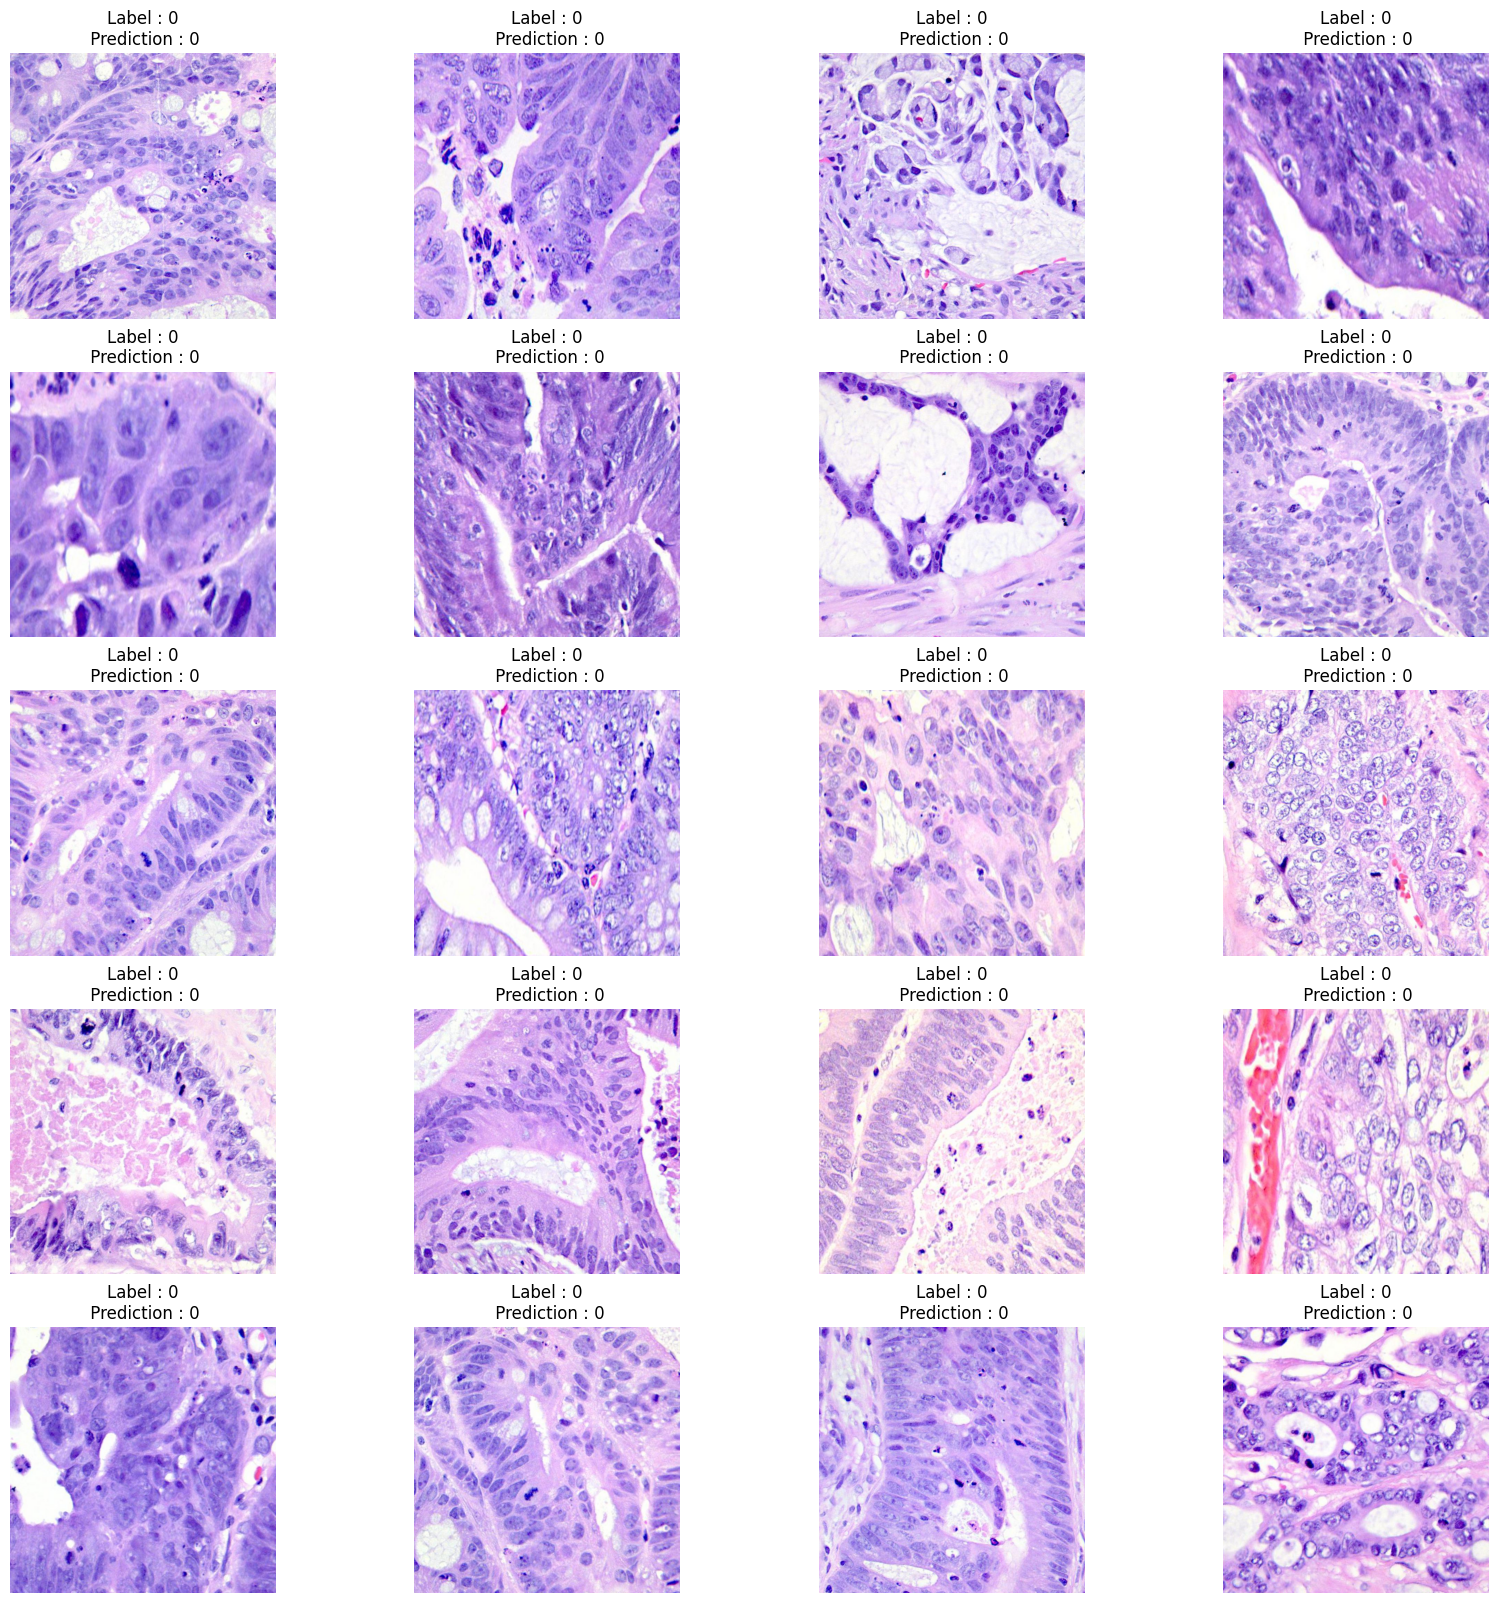

In [10]:
import matplotlib.image as mpimg

img_paths = test_paths[:20]         # first 20 image paths
img_features = features_test[:20]   # corresponding features

img_pred_encoded = classifier.predict(img_features)
img_pred = label_encoder.inverse_transform(img_pred_encoded)

plt.figure(figsize=[20, 20])
for i in range(20):
    plt.subplot(5, 4, i+1)
    image_array = mpimg.imread(img_paths[i])   # load image from file
    plt.imshow(image_array)
    plt.axis('off')
    plt.title("Label : {}\n Prediction : {}".format(
        y_test[i], img_pred[i]
    ))
plt.show()


Accuracy: 0.9943977591036415
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       0.99      0.99      0.99       500
           3       1.00      1.00      1.00       500
           4       0.99      0.99      0.99       499

    accuracy                           0.99      2499
   macro avg       0.99      0.99      0.99      2499
weighted avg       0.99      0.99      0.99      2499

Thoi gian thu thi: 45.51204586029053


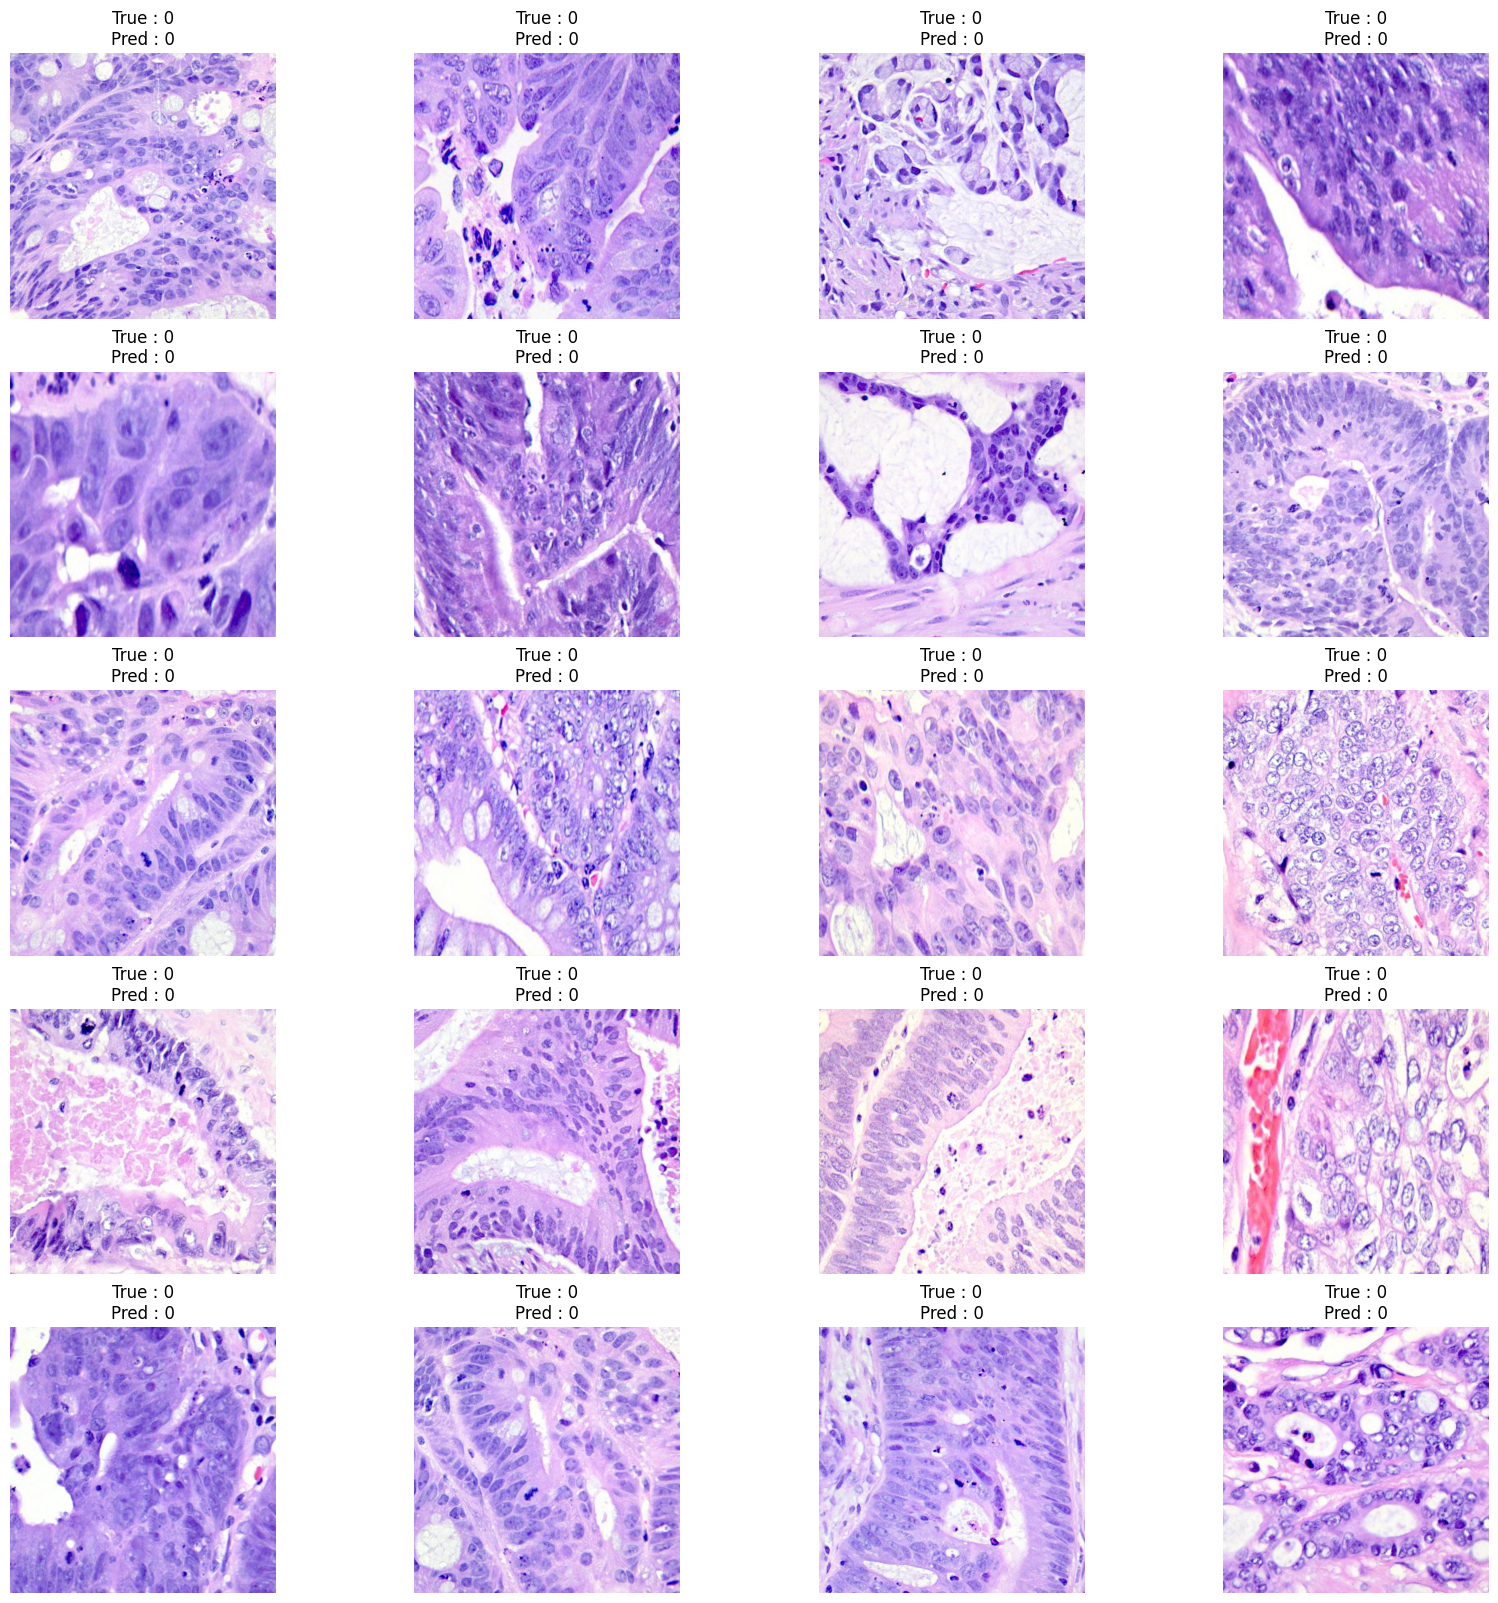

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ==========================
# 1. Encode target labels
# ==========================
st = time.time()
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# ==========================
# 2. Train XGBoost Classifier
# ==========================
classifier = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
classifier.fit(features_train, y_train_encoded)

# ==========================
# 3. Predictions on test features
# ==========================
y_pred_encoded = classifier.predict(features_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# ==========================
# 4. Evaluation
# ==========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

nd = time.time()
print("Thoi gian thu thi:", nd - st)

# ==========================
# 5. Visualization (first 20 test images)
# ==========================
img_paths = test_paths[:20]        # list of image file paths
img_features = features_test[:20]  # corresponding features for XGBoost

 
# 5. Visualization (first 20 test images)
# ==========================
img_paths = test_paths[:20]        # first 20 test image file paths
img_features = features_test[:20]  # corresponding features for XGBoost

# 🔹 Predict on these features (numeric IDs)
img_pred_encoded = classifier.predict(img_features)

plt.figure(figsize=[20, 20])
for i in range(20):
    plt.subplot(5, 4, i+1)
    image_array = mpimg.imread(img_paths[i])  # load image from path
    plt.imshow(image_array)
    plt.axis('off')
    plt.title("True : {}\nPred : {}".format(
        y_test_encoded[i],   # true numeric label
        img_pred_encoded[i]  # predicted numeric label
    ))
plt.show()


**Enhanced bayesian method**

In [12]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KernelDensity
import numpy as np
import time
st=time.time()
class KDE_NaiveBayes:
    def __init__(self, bandwidth=0.09, default_class=None):
        self.bandwidth = bandwidth
        self.kde_models = {}
        self.classes = None
        self.priors = None
        self.default_class = default_class  # Fallback class if no valid prediction

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        n_samples = len(y)

        # Calculate prior probabilities
        for c in self.classes:
            self.priors[c] = np.sum(y == c) / n_samples
        
        # Fit KDE for each feature and each class, skip if no samples
        for c in self.classes:
            X_c = X[y == c]
            if X_c.shape[0] == 0:
                print(f"Warning: No samples found for class {c}. Skipping KDE fitting.")
                self.kde_models[c] = None
                continue
            self.kde_models[c] = []
            for feature_idx in range(X.shape[1]):
                kde = KernelDensity(bandwidth=self.bandwidth, kernel='gaussian')
                kde.fit(X_c[:, feature_idx].reshape(-1, 1))
                self.kde_models[c].append(kde)

    def predict(self, X):
        n_samples = X.shape[0]
        log_probs = np.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            log_prior = np.log(self.priors[c]) if self.priors[c] > 0 else -np.inf
            if self.kde_models[c] is None:
                log_probs[:, idx] = -np.inf
                continue
            log_likelihood = np.zeros(n_samples)
            for feature_idx, kde in enumerate(self.kde_models[c]):
                feature_log_prob = kde.score_samples(X[:, feature_idx].reshape(-1, 1))
                log_likelihood += feature_log_prob
            log_probs[:, idx] = log_prior+log_likelihood
        
        # Check if all probabilities are -inf
        if np.all(log_probs == -np.inf, axis=1).any():
            if self.default_class is not None:
                print(f"Warning: Some samples have no valid class probabilities. Using default class: {self.default_class}")
                y_pred = np.array([self.default_class if np.all(log_probs[i] == -np.inf) else self.classes[np.argmax(log_probs[i])] for i in range(n_samples)])
            else:
                raise ValueError("No valid predictions possible for some samples; all classes have zero probability. Set a default_class to handle this.")
        else:
            y_pred = self.classes[np.argmax(log_probs, axis=1)]
        
        return y_pred

# Example usage
classifier = KDE_NaiveBayes(bandwidth=0.09, default_class='Normal')  # Set a default class
classifier.fit(features_train, y_train)
y_pred = classifier.predict(features_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
nd=time.time()
print("Thoi gian",nd-st)


Accuracy: 0.9351740696278511
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       500
           1       0.97      0.95      0.96       500
           2       0.88      0.88      0.88       500
           3       1.00      1.00      1.00       500
           4       0.92      0.90      0.91       499

    accuracy                           0.94      2499
   macro avg       0.94      0.94      0.94      2499
weighted avg       0.94      0.94      0.94      2499

Thoi gian 2042.9551484584808


<function matplotlib.pyplot.show(close=None, block=None)>

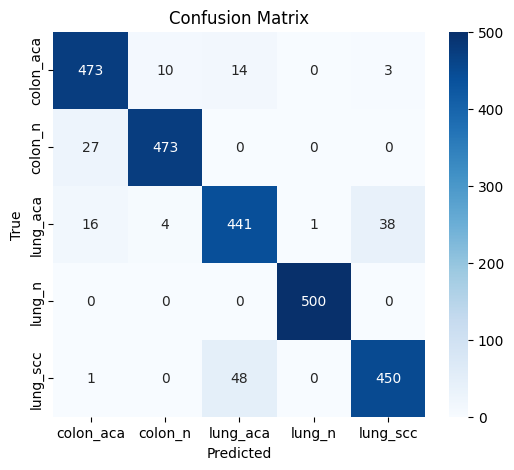

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Step 7: Evaluate the Model and Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)  # Define conf_matrix here
class_names = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
classA =[0,1,2,3,4]
# Map integer labels to class names
categories = [class_names[label] for label in classA]
# Figure 1: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_Naivebayes.png')
plt.show
# plt.close()
# print("Confusion matrix figure saved as 'confusion_matrix.png'.")

In [14]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Bắt đầu đo thời gian
st = time.time()

# Step 5: Train a Logistic Regression Classifier  
classifier = LogisticRegression(max_iter=1000)  # Tạo đối tượng LogisticRegression, điều chỉnh max_iter nếu cần thiết  
classifier.fit(features_train, y_train)  # Huấn luyện mô hình

# Step 6: Make Predictions  
y_pred = classifier.predict(features_test)  # Dự đoán với dữ liệu kiểm tra

# Step 7: Evaluate the Model  
print("Accuracy:", accuracy_score(y_test, y_pred))  # Đánh giá độ chính xác
print(classification_report(y_test, y_pred))  # In báo cáo phân loại với các chỉ số chính

# Kết thúc đo thời gian
nd = time.time()
print("Thời gian thực thi:", nd - st)  # In ra thời gian thực thi

Accuracy: 0.9959983993597439
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       0.99      0.99      0.99       500
           3       1.00      1.00      1.00       500
           4       0.99      0.99      0.99       499

    accuracy                           1.00      2499
   macro avg       1.00      1.00      1.00      2499
weighted avg       1.00      1.00      1.00      2499

Thời gian thực thi: 52.53006935119629


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<function matplotlib.pyplot.show(close=None, block=None)>

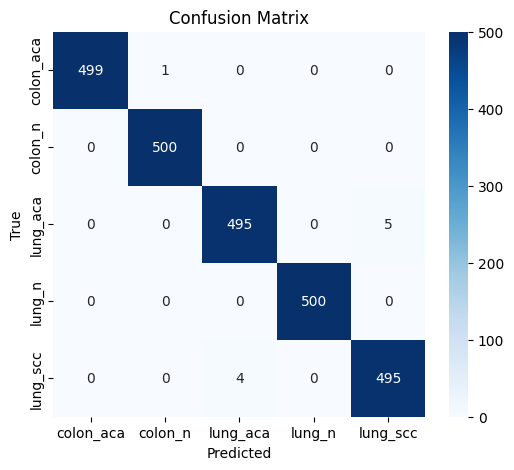

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Step 7: Evaluate the Model and Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)  # Define conf_matrix here
class_names = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
classA =[0,1,2,3,4]
# Map integer labels to class names
categories = [class_names[label] for label in classA]
# Figure 1: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_Logistic.png')
plt.show

In [16]:
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Bắt đầu đo thời gian
st = time.time()

# Step 5: Train an SVM Classifier  
classifier = SVC(kernel='rbf')  # Tạo đối tượng SVM, kernel có thể là 'linear', 'poly', 'rbf', hoặc 'sigmoid'
classifier.fit(features_train, y_train)  # Huấn luyện mô hình

# Step 6: Make Predictions  
y_pred = classifier.predict(features_test)  # Dự đoán với dữ liệu kiểm tra

# Step 7: Evaluate the Model  
print("Accuracy:", accuracy_score(y_test, y_pred))  # Đánh giá độ chính xác
print(classification_report(y_test, y_pred))  # In báo cáo phân loại với các chỉ số chính

# Kết thúc đo thời gian
nd = time.time()
print("Thời gian thực thi:", nd - st)  # In ra thời gian thực thi


Accuracy: 0.9931972789115646
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       0.98      0.99      0.98       500
           3       1.00      1.00      1.00       500
           4       0.99      0.98      0.98       499

    accuracy                           0.99      2499
   macro avg       0.99      0.99      0.99      2499
weighted avg       0.99      0.99      0.99      2499

Thời gian thực thi: 18.688189029693604


<function matplotlib.pyplot.show(close=None, block=None)>

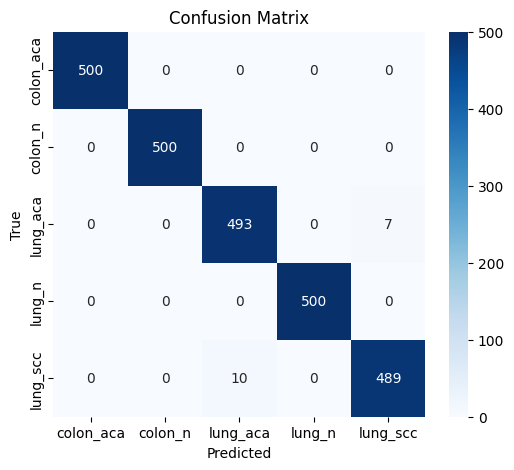

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Step 7: Evaluate the Model and Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)  # Define conf_matrix here
class_names = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
classA =[0,1,2,3,4]
# Map integer labels to class names
categories = [class_names[label] for label in classA]
# Figure 1: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_SVM.png')
plt.show

**Trich xuat dac trung su dung inception resnetv2** 

In [18]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import warnings
import timm  # For Inception-ResNet-v2
import time
import cv2
from concurrent.futures import ThreadPoolExecutor

# Start timing
st = time.time()

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Custom Dataset class
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, label_map):
        self.image_paths = image_paths
        self.labels = labels
        self.label_map = label_map
        self.preprocess = transforms.Compose([
            transforms.Resize((299, 299)),  # Inception-ResNet-v2 requires 299x299
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            image_tensor = self.preprocess(image)
            label_idx = self.label_map[label]
            return image_tensor, label_idx, img_path
        except (UnidentifiedImageError, Exception) as e:
            print(f"Error loading image {img_path}: {e}")
            return torch.zeros(3, 299, 299), -1, img_path  # Dummy for invalid image

def extract_features(
    image_paths,
    labels,
    model_name='inception_resnet_v2',
    device=None,
    batch_size=16,
    num_workers=4,
    save_features=False,
    output_dir='features',
    label_map=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    num_workers = min(num_workers, os.cpu_count() or 1)

    if len(image_paths) != len(labels):
        raise ValueError("Number of image paths and labels must match.")
    if len(image_paths) == 0:
        print("No images provided.")
        return np.array([]), np.array([]), []

    try:
        model = timm.create_model(model_name, pretrained=True)
    except Exception as e:
        raise ValueError(f"Failed to load model {model_name}: {e}")

    model.eval()
    model.to(device)

    dataset = ImageDataset(image_paths, labels, label_map=label_map)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
        pin_memory=(device != 'cpu'))

    features = []
    extracted_labels = []
    valid_paths = []

    for batch_tensors, batch_labels, batch_paths in tqdm(dataloader, desc="Extracting features"):
        batch_tensors = batch_tensors.to(device)
        valid_mask = batch_labels != -1
        if valid_mask.sum() == 0:
            continue

        with torch.no_grad():
            batch_features = model.forward_features(batch_tensors[valid_mask])
            batch_features = torch.nn.functional.adaptive_avg_pool2d(batch_features, (1, 1))
            batch_features = batch_features.view(batch_features.size(0), -1).cpu().numpy()

        features.append(batch_features)
        extracted_labels.extend(batch_labels[valid_mask].cpu().numpy())
        valid_paths.extend([batch_paths[i] for i in range(len(batch_paths)) if valid_mask[i]])

    if not features:
        print("No valid images processed.")
        return np.empty((0, model.num_features)), np.array([]), []

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)

    if save_features:
        os.makedirs(output_dir, exist_ok=True)
        np.save(os.path.join(output_dir, 'features.npy'), features)
        np.save(os.path.join(output_dir, 'labels.npy'), extracted_labels)
        with open(os.path.join(output_dir, 'valid_paths.txt'), 'w') as f:
            f.write('\n'.join(valid_paths))
        print(f"Features saved to {output_dir}")

    print(f"Extracted {features.shape[0]} features.")
    return features, extracted_labels, valid_paths

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)
def get_image_paths_and_labels(folder_path):
    image_paths = []
    labels = []
    label_map = {}
    for idx, label_name in enumerate(sorted(os.listdir(folder_path))):
        label_folder = os.path.join(folder_path, label_name)
        if os.path.isdir(label_folder):
            label_map[label_name] = idx
            for filename in os.listdir(label_folder):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(label_folder, filename))
                    labels.append(label_name)
    return image_paths, labels, label_map

# Folder paths
train_folder = "/kaggle/input/lc25000/lung_colon_image_set/Train and Validation Set"
test_folder = "/kaggle/input/lc25000/lung_colon_image_set/Test Set"

# Load image paths and labels
x_train_paths, y_train, train_label_map = get_image_paths_and_labels(train_folder)
x_test_paths, y_test, test_label_map = get_image_paths_and_labels(test_folder)

# Confirm device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


# Extract test features
print("Extracting features for test set...")
xtest_features, y_test_labels, _ = extract_features(
    x_test_paths,
    y_test,
    model_name='inception_resnet_v2',
    device=device,
    batch_size=16,
    num_workers=4,
    save_features=True,
    output_dir='test_features',
    label_map=test_label_map
)
# Extract train features
print("Extracting features for training set...")
xtrain_features, y_train_labels, _ = extract_features(
    x_train_paths,
    y_train,
    model_name='inception_resnet_v2',
    device=device,
    batch_size=16,
    num_workers=4,
    save_features=True,
    output_dir='train_features',
    label_map=train_label_map
)

# Output shapes
print(f"Train features shape: {xtrain_features.shape}")
print(f"Train labels shape: {y_train_labels.shape}")
print(f"Test features shape: {xtest_features.shape}")
print(f"Test labels shape: {y_test_labels.shape}")

# End timing
end = time.time()
print(f"Total execution time: {end - st:.2f} seconds")


Using device: cuda
Extracting features for test set...


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Extracting features: 100%|██████████| 157/157 [00:30<00:00,  5.16it/s]


Features saved to test_features
Extracted 2499 features.
Extracting features for training set...


Extracting features: 100%|██████████| 1407/1407 [04:03<00:00,  5.78it/s]

Features saved to train_features
Extracted 22501 features.
Train features shape: (22501, 1536)
Train labels shape: (22501,)
Test features shape: (2499, 1536)
Test labels shape: (2499,)
Total execution time: 277.02 seconds


In [19]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KernelDensity
import numpy as np
import time
st=time.time()
class KDE_NaiveBayes:
    def __init__(self, bandwidth=0.05, default_class=None):
        self.bandwidth = bandwidth
        self.kde_models = {}
        self.classes = None
        self.priors = None
        self.default_class = default_class  # Fallback class if no valid prediction

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        n_samples = len(y)

        # Calculate prior probabilities
        for c in self.classes:
            self.priors[c] = np.sum(y == c) / n_samples
        
        # Fit KDE for each feature and each class, skip if no samples
        for c in self.classes:
            X_c = X[y == c]
            if X_c.shape[0] == 0:
                print(f"Warning: No samples found for class {c}. Skipping KDE fitting.")
                self.kde_models[c] = None
                continue
            self.kde_models[c] = []
            for feature_idx in range(X.shape[1]):
                kde = KernelDensity(bandwidth=self.bandwidth, kernel='gaussian')
                kde.fit(X_c[:, feature_idx].reshape(-1, 1))
                self.kde_models[c].append(kde)

    def predict(self, X):
        n_samples = X.shape[0]
        log_probs = np.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            log_prior = np.log(self.priors[c]) if self.priors[c] > 0 else -np.inf
            if self.kde_models[c] is None:
                log_probs[:, idx] = -np.inf
                continue
            log_likelihood = np.zeros(n_samples)
            for feature_idx, kde in enumerate(self.kde_models[c]):
                feature_log_prob = kde.score_samples(X[:, feature_idx].reshape(-1, 1))
                log_likelihood += feature_log_prob
            log_probs[:, idx] = log_prior+log_likelihood
        
        # Check if all probabilities are -inf
        if np.all(log_probs == -np.inf, axis=1).any():
            if self.default_class is not None:
                print(f"Warning: Some samples have no valid class probabilities. Using default class: {self.default_class}")
                y_pred = np.array([self.default_class if np.all(log_probs[i] == -np.inf) else self.classes[np.argmax(log_probs[i])] for i in range(n_samples)])
            else:
                raise ValueError("No valid predictions possible for some samples; all classes have zero probability. Set a default_class to handle this.")
        else:
            y_pred = self.classes[np.argmax(log_probs, axis=1)]
        
        return y_pred

# Example usage
classifier = KDE_NaiveBayes(bandwidth=0.05, default_class='Normal')  # Set a default class
classifier.fit(xtrain_features, y_train_labels)
y_pred = classifier.predict(xtest_features)

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print(classification_report(y_test_labels, y_pred))
nd=time.time()
print("Thoi gian",nd-st)


Accuracy: 0.9303721488595438
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       500
           1       0.98      0.98      0.98       500
           2       0.87      0.82      0.85       500
           3       1.00      0.99      1.00       500
           4       0.84      0.88      0.86       499

    accuracy                           0.93      2499
   macro avg       0.93      0.93      0.93      2499
weighted avg       0.93      0.93      0.93      2499

Thoi gian 4205.921687364578


In [20]:
import os
import numpy as np
import pandas as pd
import torch
from torchvision import transforms
from transformers import ViTModel, ViTFeatureExtractor
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder  # <-- add this
from tensorflow.keras.utils import to_categorical

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import time
st=time.time()
# Step 5: Train a Naive Bayes Classifier  
classifier = GaussianNB()  
classifier.fit(xtrain_features, y_train_labels)  # Training the classifier  

# Step 6: Make Predictions  
y_pred = classifier.predict(xtest_features)  

# Step 7: Evaluate the Model  
print("Accuracy:", accuracy_score(y_test_labels, y_pred))  
print(classification_report(y_test_labels, y_pred))  
nd=time.time()
print("Thoi gian thu thi", nd-st)

Accuracy: 0.9091636654661864
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       500
           1       0.96      0.98      0.97       500
           2       0.85      0.72      0.78       500
           3       1.00      0.99      1.00       500
           4       0.79      0.87      0.83       499

    accuracy                           0.91      2499
   macro avg       0.91      0.91      0.91      2499
weighted avg       0.91      0.91      0.91      2499

Thoi gian thu thi 0.4140889644622803


**2. Inception v3 Features**

In [22]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import warnings
import timm  # For Inception-ResNet-v2
import time
import cv2
from concurrent.futures import ThreadPoolExecutor

# Start timing
st = time.time()

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Custom Dataset class
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, label_map):
        self.image_paths = image_paths
        self.labels = labels
        self.label_map = label_map
        self.preprocess = transforms.Compose([
            transforms.Resize((299, 299)),  # Inception-ResNet-v2 requires 299x299
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            image_tensor = self.preprocess(image)
            label_idx = self.label_map[label]
            return image_tensor, label_idx, img_path
        except (UnidentifiedImageError, Exception) as e:
            print(f"Error loading image {img_path}: {e}")
            return torch.zeros(3, 299, 299), -1, img_path  # Dummy for invalid image

def extract_features(
    image_paths,
    labels,
    model_name='inception_resnet_v2',
    device=None,
    batch_size=16,
    num_workers=4,
    save_features=False,
    output_dir='features',
    label_map=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    num_workers = min(num_workers, os.cpu_count() or 1)

    if len(image_paths) != len(labels):
        raise ValueError("Number of image paths and labels must match.")
    if len(image_paths) == 0:
        print("No images provided.")
        return np.array([]), np.array([]), []

    try:
        model = timm.create_model(model_name, pretrained=True)
    except Exception as e:
        raise ValueError(f"Failed to load model {model_name}: {e}")

    model.eval()
    model.to(device)

    dataset = ImageDataset(image_paths, labels, label_map=label_map)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
        pin_memory=(device != 'cpu'))

    features = []
    extracted_labels = []
    valid_paths = []

    for batch_tensors, batch_labels, batch_paths in tqdm(dataloader, desc="Extracting features"):
        batch_tensors = batch_tensors.to(device)
        valid_mask = batch_labels != -1
        if valid_mask.sum() == 0:
            continue

        with torch.no_grad():
            batch_features = model.forward_features(batch_tensors[valid_mask])
            batch_features = torch.nn.functional.adaptive_avg_pool2d(batch_features, (1, 1))
            batch_features = batch_features.view(batch_features.size(0), -1).cpu().numpy()

        features.append(batch_features)
        extracted_labels.extend(batch_labels[valid_mask].cpu().numpy())
        valid_paths.extend([batch_paths[i] for i in range(len(batch_paths)) if valid_mask[i]])

    if not features:
        print("No valid images processed.")
        return np.empty((0, model.num_features)), np.array([]), []

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)

    if save_features:
        os.makedirs(output_dir, exist_ok=True)
        np.save(os.path.join(output_dir, 'features.npy'), features)
        np.save(os.path.join(output_dir, 'labels.npy'), extracted_labels)
        with open(os.path.join(output_dir, 'valid_paths.txt'), 'w') as f:
            f.write('\n'.join(valid_paths))
        print(f"Features saved to {output_dir}")

    print(f"Extracted {features.shape[0]} features.")
    return features, extracted_labels, valid_paths

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)
def get_image_paths_and_labels(folder_path):
    image_paths = []
    labels = []
    label_map = {}
    for idx, label_name in enumerate(sorted(os.listdir(folder_path))):
        label_folder = os.path.join(folder_path, label_name)
        if os.path.isdir(label_folder):
            label_map[label_name] = idx
            for filename in os.listdir(label_folder):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(label_folder, filename))
                    labels.append(label_name)
    return image_paths, labels, label_map

# Folder paths
train_folder = "/kaggle/input/lc25000/lung_colon_image_set/Train and Validation Set"
test_folder = "/kaggle/input/lc25000/lung_colon_image_set/Test Set"

# Load image paths and labels
x_train_paths, y_train, train_label_map = get_image_paths_and_labels(train_folder)
x_test_paths, y_test, test_label_map = get_image_paths_and_labels(test_folder)

# Confirm device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


# Extract test features
print("Extracting features for test set...")
xtest_features, y_test_labels, _ = extract_features(
    x_test_paths,
    y_test,
    model_name='inception_v3',
    device=device,
    batch_size=16,
    num_workers=4,
    save_features=True,
    output_dir='test_features',
    label_map=test_label_map
)
# Extract train features
print("Extracting features for training set...")
xtrain_features, y_train_labels, _ = extract_features(
    x_train_paths,
    y_train,
    model_name='inception_v3',
    device=device,
    batch_size=16,
    num_workers=4,
    save_features=True,
    output_dir='train_features',
    label_map=train_label_map
)

# Output shapes
print(f"Train features shape: {xtrain_features.shape}")
print(f"Train labels shape: {y_train_labels.shape}")
print(f"Test features shape: {xtest_features.shape}")
print(f"Test labels shape: {y_test_labels.shape}")

# End timing
end = time.time()
print(f"Total execution time: {end - st:.2f} seconds")


Using device: cuda
Extracting features for test set...


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Extracting features: 100%|██████████| 157/157 [00:15<00:00, 10.10it/s]


Features saved to test_features
Extracted 2499 features.
Extracting features for training set...


Extracting features: 100%|██████████| 1407/1407 [02:12<00:00, 10.61it/s]


Features saved to train_features
Extracted 22501 features.
Train features shape: (22501, 2048)
Train labels shape: (22501,)
Test features shape: (2499, 2048)
Test labels shape: (2499,)
Total execution time: 150.32 seconds


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import time
st=time.time()
# Step 5: Train a Naive Bayes Classifier  
classifier = GaussianNB()  
classifier.fit(xtrain_features, y_train_labels)  # Training the classifier  

# Step 6: Make Predictions  
y_pred = classifier.predict(xtest_features)  

# Step 7: Evaluate the Model  
print("Accuracy:", accuracy_score(y_test_labels, y_pred))  
print(classification_report(y_test_labels, y_pred))  
nd=time.time()
print("Thoi gian thu thi", nd-st)

Accuracy: 0.9263705482192878
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       500
           1       0.98      0.96      0.97       500
           2       0.87      0.85      0.86       500
           3       0.98      0.99      0.99       500
           4       0.88      0.89      0.89       499

    accuracy                           0.93      2499
   macro avg       0.93      0.93      0.93      2499
weighted avg       0.93      0.93      0.93      2499

Thoi gian thu thi 0.4825472831726074


In [24]:
from cuml.neighbors import KernelDensity as cuKDE  # GPU version
import cupy as cp  # GPU array (like numpy)
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import time

class KDE_NaiveBayes_GPU:
    def __init__(self, bandwidth=0.05, default_class=None):
        self.bandwidth = bandwidth
        self.kde_models = {}
        self.classes = None
        self.priors = None
        self.default_class = default_class

    def fit(self, X, y):
        X = cp.asarray(X)  # move to GPU
        y = cp.asarray(y)
        self.classes = cp.unique(y)
        self.priors = {}
        n_samples = len(y)

        for c in self.classes:
            class_mask = (y == c)
            self.priors[c.item()] = cp.sum(class_mask).item() / n_samples
            X_c = X[class_mask]
            if X_c.shape[0] == 0:
                print(f"Warning: No samples for class {c}. Skipping KDE.")
                self.kde_models[c.item()] = None
                continue
            self.kde_models[c.item()] = []
            for feature_idx in range(X.shape[1]):
                kde = cuKDE(kernel='gaussian', bandwidth=self.bandwidth)
                kde.fit(X_c[:, feature_idx])
                self.kde_models[c.item()].append(kde)

    def predict(self, X):
        X = cp.asarray(X)
        n_samples = X.shape[0]
        log_probs = cp.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            class_value = c.item()
            log_prior = cp.log(self.priors[class_value]) if self.priors[class_value] > 0 else -cp.inf
            if self.kde_models[class_value] is None:
                log_probs[:, idx] = -cp.inf
                continue
            log_likelihood = cp.zeros(n_samples)
            for feature_idx, kde in enumerate(self.kde_models[class_value]):
                feature_log_prob = kde.score_samples(X[:, feature_idx])
                log_likelihood += feature_log_prob
            log_probs[:, idx] = log_prior + log_likelihood

        y_pred = []
        for i in range(n_samples):
            if cp.all(log_probs[i] == -cp.inf):
                if self.default_class is not None:
                    print(f"Warning: Sample {i} has no valid probabilities. Using default class.")
                    y_pred.append(self.default_class)
                else:
                    raise ValueError(f"Sample {i}: No valid prediction and no default_class provided.")
            else:
                pred_class = self.classes[cp.argmax(log_probs[i])].item()
                y_pred.append(pred_class)

        return np.array(y_pred)  # back to CPU

# ======================
# Example usage
# ======================
# Replace the following with your actual data:
# xtrain_features, xtest_features = shape (n_samples, n_features)
# y_train_labels, y_test_labels = shape (n_samples,)

# You must have your xtrain_features, y_train_labels, xtest_features, y_test_labels defined
# Example placeholders (remove or replace with real data):
# xtrain_features = np.random.rand(100, 10)
# y_train_labels = np.random.choice(['Normal', 'Anomaly'], 100)
# xtest_features = np.random.rand(20, 10)
# y_test_labels = np.random.choice(['Normal', 'Anomaly'], 20)

st = time.time()
classifier = KDE_NaiveBayes_GPU(bandwidth=0.05, default_class='Normal')
classifier.fit(xtrain_features, y_train_labels)
y_pred = classifier.predict(xtest_features)

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print(classification_report(y_test_labels, y_pred))
print("Thời gian:", time.time() - st)


Accuracy: 0.9375750300120048
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       500
           1       0.98      0.96      0.97       500
           2       0.88      0.88      0.88       500
           3       0.98      1.00      0.99       500
           4       0.91      0.89      0.90       499

    accuracy                           0.94      2499
   macro avg       0.94      0.94      0.94      2499
weighted avg       0.94      0.94      0.94      2499

Thời gian: 129.23857498168945


**VGG16**

In [25]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm
import warnings
import time
import cv2
from concurrent.futures import ThreadPoolExecutor

# Start timing
st = time.time()
warnings.filterwarnings("ignore")

class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, label_map):
        self.image_paths = image_paths
        self.labels = labels
        self.label_map = label_map
        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),  # VGG16 uses 224x224
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            image_tensor = self.preprocess(image)
            label_idx = self.label_map[label]
            return image_tensor, label_idx, img_path
        except (UnidentifiedImageError, Exception) as e:
            print(f"Error loading image {img_path}: {e}")
            return torch.zeros(3, 224, 224), -1, img_path  # Dummy for invalid image

def extract_features(image_paths, labels, device=None,
                     batch_size=16, num_workers=4, save_features=False,
                     output_dir='features', label_map=None):

    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if len(image_paths) != len(labels):
        raise ValueError("Number of image paths and labels must match.")
    if len(image_paths) == 0:
        print("No images provided.")
        return np.array([]), np.array([]), []

    # Load pretrained VGG16
    model = models.vgg16(pretrained=True)
    model = model.features  # Use only the convolutional base
    model.eval().to(device)

    dataset = ImageDataset(image_paths, labels, label_map=label_map)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            num_workers=num_workers, shuffle=False,
                            pin_memory=(device != 'cpu'))

    features, extracted_labels, valid_paths = [], [], []

    for batch_tensors, batch_labels, batch_paths in tqdm(dataloader, desc="Extracting features"):
        batch_tensors = batch_tensors.to(device)
        valid_mask = batch_labels != -1
        if valid_mask.sum() == 0:
            continue

        with torch.no_grad():
            # Pass through VGG16 convolutional layers
            conv_feats = model(batch_tensors[valid_mask])
            # Apply global average pooling to get [B, 512]
            batch_feat = torch.nn.functional.adaptive_avg_pool2d(conv_feats, (1, 1)).view(conv_feats.size(0), -1)
            batch_feat = batch_feat.cpu().numpy()

        features.append(batch_feat)
        extracted_labels.extend(batch_labels[valid_mask].cpu().numpy())
        valid_paths.extend([batch_paths[i] for i in range(len(batch_paths)) if valid_mask[i]])

    if not features:
        print("No valid images processed.")
        return np.empty((0, 512)), np.array([]), []

    features = np.concatenate(features, axis=0)
    extracted_labels = np.array(extracted_labels)

    if save_features:
        os.makedirs(output_dir, exist_ok=True)
        np.save(os.path.join(output_dir, 'features.npy'), features)
        np.save(os.path.join(output_dir, 'labels.npy'), extracted_labels)
        with open(os.path.join(output_dir, 'valid_paths.txt'), 'w') as f:
            f.write('\n'.join(valid_paths))
        print(f"Features saved to {output_dir}")

    print(f"Extracted {features.shape[0]} features.")
    return features, extracted_labels, valid_paths

def get_image_paths_and_labels(folder_path):
    image_paths, labels, label_map = [], [], {}
    for idx, label_name in enumerate(sorted(os.listdir(folder_path))):
        label_folder = os.path.join(folder_path, label_name)
        if os.path.isdir(label_folder):
            label_map[label_name] = idx
            for filename in os.listdir(label_folder):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(label_folder, filename))
                    labels.append(label_name)
    return image_paths, labels, label_map

# Folder paths
train_folder = "/kaggle/input/lc25000/lung_colon_image_set/Train and Validation Set"
test_folder = "/kaggle/input/lc25000/lung_colon_image_set/Test Set"

# Load image paths and labels
x_train_paths, y_train, train_label_map = get_image_paths_and_labels(train_folder)
x_test_paths, y_test, test_label_map = get_image_paths_and_labels(test_folder)

# Confirm device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Extract test features
print("Extracting features for test set...")
xtest_features, y_test_labels, _ = extract_features(
    x_test_paths, y_test, device=device, batch_size=16,
    num_workers=4, save_features=True,
    output_dir='test_features', label_map=test_label_map
)

# Extract train features
print("Extracting features for training set...")
xtrain_features, y_train_labels, _ = extract_features(
    x_train_paths, y_train, device=device, batch_size=16,
    num_workers=4, save_features=True,
    output_dir='train_features', label_map=train_label_map
)

# Output shapes
print(f"Train features shape: {xtrain_features.shape}")
print(f"Train labels shape: {y_train_labels.shape}")
print(f"Test features shape: {xtest_features.shape}")
print(f"Test labels shape: {y_test_labels.shape}")

# End timing
end = time.time()
print(f"Total execution time: {end - st:.2f} seconds")


Using device: cuda
Extracting features for test set...


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 194MB/s]
Extracting features: 100%|██████████| 157/157 [00:14<00:00, 10.75it/s]


Features saved to test_features
Extracted 2499 features.
Extracting features for training set...


Extracting features: 100%|██████████| 1407/1407 [01:58<00:00, 11.86it/s]

Features saved to train_features
Extracted 22501 features.
Train features shape: (22501, 512)
Train labels shape: (22501,)
Test features shape: (2499, 512)
Test labels shape: (2499,)
Total execution time: 139.89 seconds


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import time
st=time.time()
# Step 5: Train a Naive Bayes Classifier  
classifier = GaussianNB()  
classifier.fit(xtrain_features, y_train_labels)  # Training the classifier  

# Step 6: Make Predictions  
y_pred = classifier.predict(xtest_features)  

# Step 7: Evaluate the Model  
print("Accuracy:", accuracy_score(y_test_labels, y_pred))  
print(classification_report(y_test_labels, y_pred))  
nd=time.time()
print("Thoi gian thu thi", nd-st)

Accuracy: 0.8803521408563425
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       500
           1       0.97      0.91      0.94       500
           2       0.83      0.71      0.76       500
           3       0.98      0.99      0.98       500
           4       0.76      0.88      0.82       499

    accuracy                           0.88      2499
   macro avg       0.88      0.88      0.88      2499
weighted avg       0.88      0.88      0.88      2499

Thoi gian thu thi 0.2603189945220947


In [27]:
from cuml.neighbors import KernelDensity as cuKDE  # GPU version
import cupy as cp  # GPU array (like numpy)
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import time

class KDE_NaiveBayes_GPU:
    def __init__(self, bandwidth=0.05, default_class=None):
        self.bandwidth = bandwidth
        self.kde_models = {}
        self.classes = None
        self.priors = None
        self.default_class = default_class

    def fit(self, X, y):
        X = cp.asarray(X)  # move to GPU
        y = cp.asarray(y)
        self.classes = cp.unique(y)
        self.priors = {}
        n_samples = len(y)

        for c in self.classes:
            class_mask = (y == c)
            self.priors[c.item()] = cp.sum(class_mask).item() / n_samples
            X_c = X[class_mask]
            if X_c.shape[0] == 0:
                print(f"Warning: No samples for class {c}. Skipping KDE.")
                self.kde_models[c.item()] = None
                continue
            self.kde_models[c.item()] = []
            for feature_idx in range(X.shape[1]):
                kde = cuKDE(kernel='gaussian', bandwidth=self.bandwidth)
                kde.fit(X_c[:, feature_idx])
                self.kde_models[c.item()].append(kde)

    def predict(self, X):
        X = cp.asarray(X)
        n_samples = X.shape[0]
        log_probs = cp.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            class_value = c.item()
            log_prior = cp.log(self.priors[class_value]) if self.priors[class_value] > 0 else -cp.inf
            if self.kde_models[class_value] is None:
                log_probs[:, idx] = -cp.inf
                continue
            log_likelihood = cp.zeros(n_samples)
            for feature_idx, kde in enumerate(self.kde_models[class_value]):
                feature_log_prob = kde.score_samples(X[:, feature_idx])
                log_likelihood += feature_log_prob
            log_probs[:, idx] = log_prior + log_likelihood

        y_pred = []
        for i in range(n_samples):
            if cp.all(log_probs[i] == -cp.inf):
                if self.default_class is not None:
                    print(f"Warning: Sample {i} has no valid probabilities. Using default class.")
                    y_pred.append(self.default_class)
                else:
                    raise ValueError(f"Sample {i}: No valid prediction and no default_class provided.")
            else:
                pred_class = self.classes[cp.argmax(log_probs[i])].item()
                y_pred.append(pred_class)

        return np.array(y_pred)  # back to CPU

# ======================
# Example usage
# ======================
# Replace the following with your actual data:
# xtrain_features, xtest_features = shape (n_samples, n_features)
# y_train_labels, y_test_labels = shape (n_samples,)

# You must have your xtrain_features, y_train_labels, xtest_features, y_test_labels defined
# Example placeholders (remove or replace with real data):
# xtrain_features = np.random.rand(100, 10)
# y_train_labels = np.random.choice(['Normal', 'Anomaly'], 100)
# xtest_features = np.random.rand(20, 10)
# y_test_labels = np.random.choice(['Normal', 'Anomaly'], 20)

st = time.time()
classifier = KDE_NaiveBayes_GPU(bandwidth=0.05, default_class='Normal')
classifier.fit(xtrain_features, y_train_labels)
y_pred = classifier.predict(xtest_features)

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print(classification_report(y_test_labels, y_pred))
print("Thời gian:", time.time() - st)


Accuracy: 0.923969587835134
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       500
           1       0.98      0.92      0.95       500
           2       0.87      0.87      0.87       500
           3       0.98      0.99      0.99       500
           4       0.85      0.91      0.88       499

    accuracy                           0.92      2499
   macro avg       0.93      0.92      0.92      2499
weighted avg       0.93      0.92      0.92      2499

Thời gian: 30.559597730636597
